# LangChain快速入门

## 准备工作

首先，要使用LangChain必须先安装依赖，命令如下：
```shell
uv add langchain
```

LangChain支持各种不同的模型，而且提供了对应的兼容SDK，不过也都需要安装对应依赖，你可以按需添加：
```shell
# 集成 阿里百炼
uv add langchain-community dashscope

# 集成 OpenAI
uv add langchain-openai

# 集成 Anthropic
uv add langchain-anthropic
```


接下来就可以开发Agent了，基本步骤如下：
1. 加载环境变量
2. 定义工具
3. 定义Agent
4. 调用Agent


## 1.加载环境变量

In [1]:
# 1.加载环境变量
from dotenv import load_dotenv

load_dotenv()

True

## 2.定义工具



In [2]:
# 2.定义工具
from langchain.tools import tool

@tool
def get_weather(location: str) -> str:
    """
    Get the weather in a given location.
    Args:
        location: city name or coordinates
    """
    return f"Current weather in {location} is sunny"

## 3.创建Agent


In [4]:
# 3.创建Agent
from langchain.agents import create_agent
from langchain_openai import ChatOpenAI
import os

# 显式初始化 Qwen 模型（走 OpenAI 兼容协议）
llm = ChatOpenAI(
    model="qwen3.7-max-2026-06-08",
    base_url="https://dashscope.aliyuncs.com/compatible-mode/v1",
    api_key= os.getenv("DASHSCOPE_API_KEY")
)

agent = create_agent(
    model=llm,  # 直接传入模型实例，而不是字符串
    tools=[get_weather]
)

## 4.发起调用

In [5]:
# 4.调用Agent
print("🚀 正在调用大模型...")
response = agent.invoke({
    "messages": [
        {"role": "user", "content": "广州今天天气如何?"}
    ]
})

🚀 正在调用大模型...


Failed to multipart ingest runs: langsmith.utils.LangSmithError: Failed to POST https://api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')
Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')
Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')
Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 

In [6]:
print(response)

{'messages': [HumanMessage(content='广州今天天气如何?', additional_kwargs={}, response_metadata={}, id='58d0c9ed-f2b5-4b35-b695-276db7c9cb80'), AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 59, 'prompt_tokens': 286, 'total_tokens': 345, 'completion_tokens_details': {'accepted_prediction_tokens': None, 'audio_tokens': None, 'reasoning_tokens': 29, 'rejected_prediction_tokens': None, 'text_tokens': 59}, 'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 0, 'text_tokens': 286}}, 'model_provider': 'openai', 'model_name': 'qwen3.7-max-2026-06-08', 'system_fingerprint': None, 'id': 'chatcmpl-2456be07-812f-9767-b914-976a25c69214', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019ed624-f57b-7181-8875-f0ea3eff0316-0', tool_calls=[{'name': 'get_weather', 'args': {'location': '广州'}, 'id': 'call_b3cce7606f5a467cbc91bc9e', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 286, 'out

<h1 style="font-size: 28px; margin-bottom: 20px; color: #2c3e50; font-weight: bold; border-left: 4px solid #3498db; padding-left: 15px;">Agent 执行流程:</h1>
<div style="display: flex; gap: 30px; align-items: flex-start;">
    <div style="flex: 1; min-width: 0;">
        <ul style="list-style: none; padding: 0; margin: 0;">
            <li style="margin-bottom: 12px; padding: 12px 15px; background: #f8f9fa; border-left: 1px solid #667eea; border-radius: 6px; color: #2c3e50; font-size: 16px; font-weight: 600;">
                <span style="display: inline-block; width: 24px; height: 24px; background: #667eea; border-radius: 50%; text-align: center; line-height: 24px; margin-right: 8px; font-size: 14px; color: white;">1</span>
                用户提问（Input）
            </li>
            <li style="margin-bottom: 12px; padding: 12px 15px; background: #f8f9fa; border-left: 1px solid #f093fb; border-radius: 6px; color: #2c3e50; font-size: 16px; font-weight: 600;">
                <span style="display: inline-block; width: 24px; height: 24px; background: #f093fb; border-radius: 50%; text-align: center; line-height: 24px; margin-right: 8px; font-size: 14px; color: white;">2</span>
                模型分析（Reasoning）：<span style="font-size: 13px; color: #6c757d; font-weight: normal;">分析需求，规划任务，判断是否需要调用工具，调用哪个工具</span>
            </li>
            <li style="margin-bottom: 12px; padding: 12px 15px; background: #f8f9fa; border-left: 1px solid #4facfe; border-radius: 6px; color: #2c3e50; font-size: 16px; font-weight: 600;">
                <span style="display: inline-block; width: 24px; height: 24px; background: #4facfe; border-radius: 50%; text-align: center; line-height: 24px; margin-right: 8px; font-size: 14px; color: white;">3</span>
                调用工具（Action）
            </li>
            <li style="margin-bottom: 12px; padding: 12px 15px; background: #f8f9fa; border-left: 1px solid #43e97b; border-radius: 6px; color: #2c3e50; font-size: 16px; font-weight: 600;">
                <span style="display: inline-block; width: 24px; height: 24px; background: #43e97b; border-radius: 50%; text-align: center; line-height: 24px; margin-right: 8px; font-size: 14px; color: white;">4</span>
                感知分析（Observation）：<span style="font-size: 13px; color: #6c757d; font-weight: normal;">分析工具返回结果，判断是否足以完成目标，不足则继续前面步骤</span>
            </li>
            <li style="margin-bottom: 12px; padding: 12px 15px; background: #f8f9fa; border-left: 1px solid #fa709a; border-radius: 6px; color: #2c3e50; font-size: 16px; font-weight: 600;">
                <span style="display: inline-block; width: 24px; height: 24px; background: #fa709a; border-radius: 50%; text-align: center; line-height: 24px; margin-right: 8px; font-size: 14px; color: white;">5</span>
                生成结果（Output）
            </li>
        </ul>
    </div>
    <div style="flex-shrink: 0;">
        <img src="resources/f0c51e45-fe42-4f6d-80de-1e6331740b5a.png" style="width: 600px; height: auto; display: block; border-radius: 10px; box-shadow: 0 4px 15px rgba(0, 0, 0, 0.15); border: 2px solid #e0e0e0;">
    </div>
</div>

# Agent如何知道工具信息

![image.png](resources/agent.png)



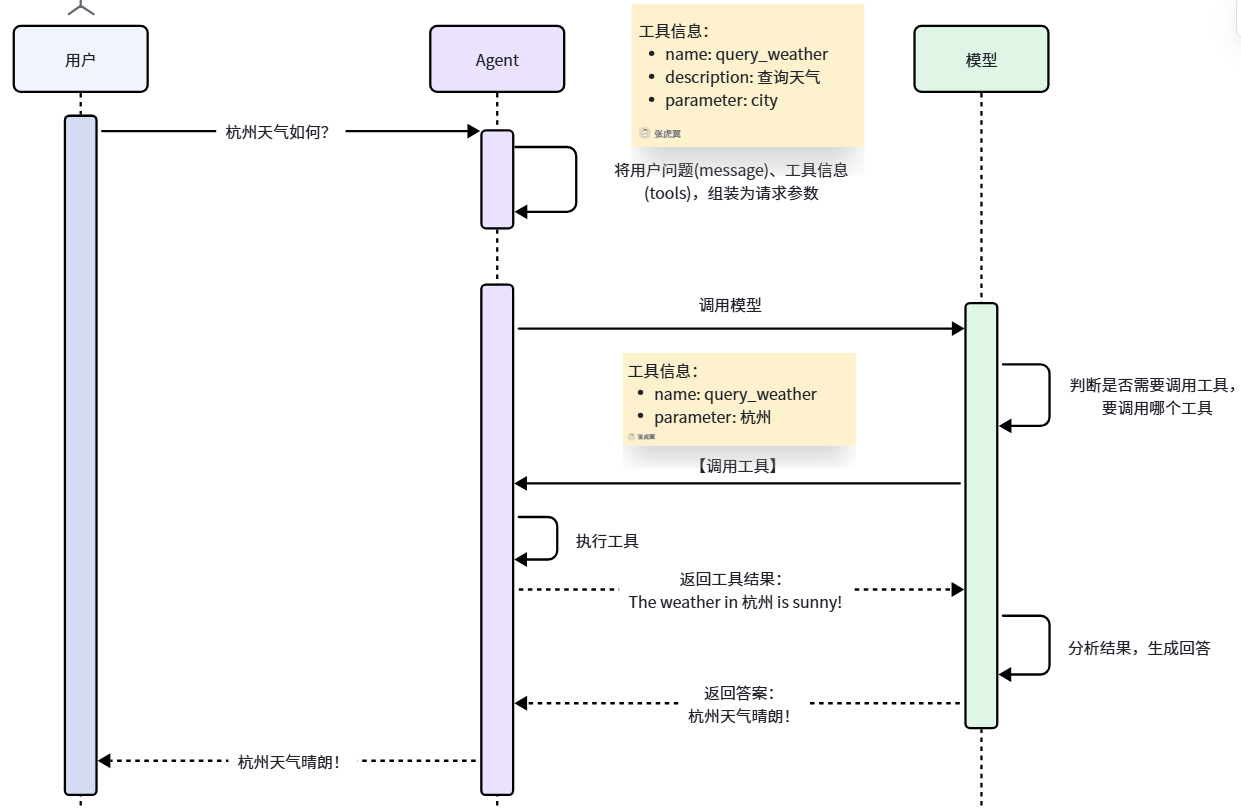